In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.metrics import *
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

In [38]:
dataset=pd.read_csv("admission_predict.csv")
dataset.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [39]:
dataset.rename(columns={'CGPA':'GPA'},inplace=True)
dataset.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,GPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [40]:
dataset.rename(columns={'GPA':'GPA Scores'},inplace= True)

Text(0, 0.5, 'Frequency')

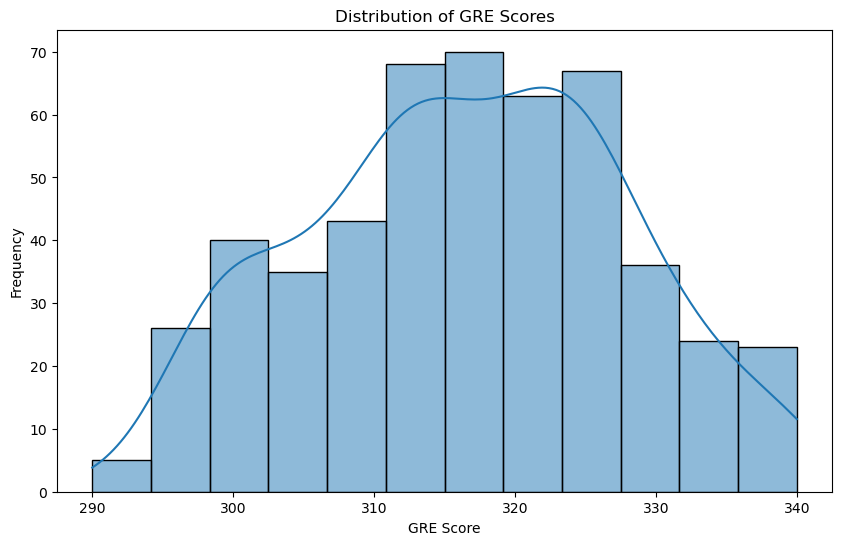

In [41]:
# GRE Scores distribution (Graduate record examination)

plt.figure(figsize=(10, 6))

sb.histplot(dataset['GRE Score'], kde=True)

plt.title('Distribution of GRE Scores')
plt.xlabel('GRE Score')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

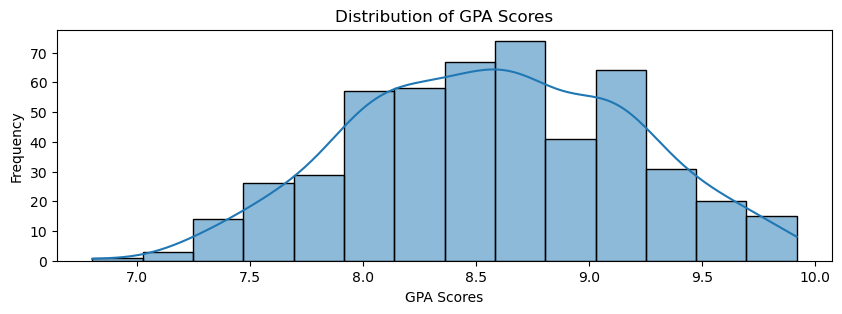

In [42]:
# GPA Scores distribution (Grade point average)
plt.figure(figsize=(10, 3))
sb.histplot(dataset['GPA Scores'], kde=True)

plt.title('Distribution of GPA Scores')
plt.xlabel('GPA Scores')
plt.ylabel('Frequency')

Text(0, 0.5, 'Number of Students')

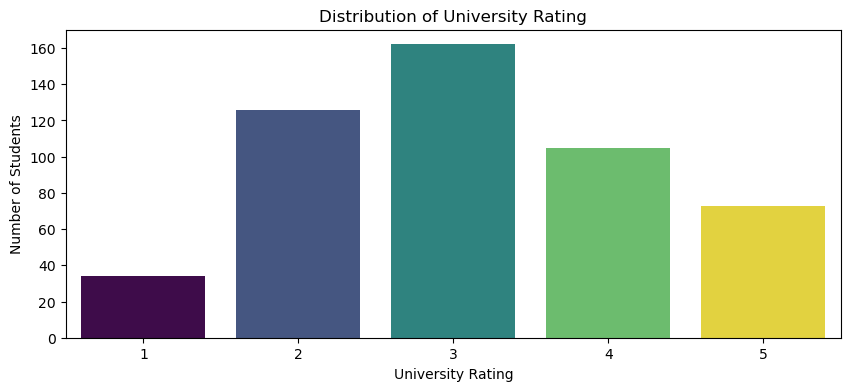

In [43]:
plt.figure(figsize=(10, 4))

sb.countplot(x='University Rating',hue='University Rating', data=dataset, palette='viridis',legend=False)

plt.title('Distribution of University Rating')
plt.xlabel('University Rating')
plt.ylabel('Number of Students')

Text(0, 0.5, 'Number of Students')

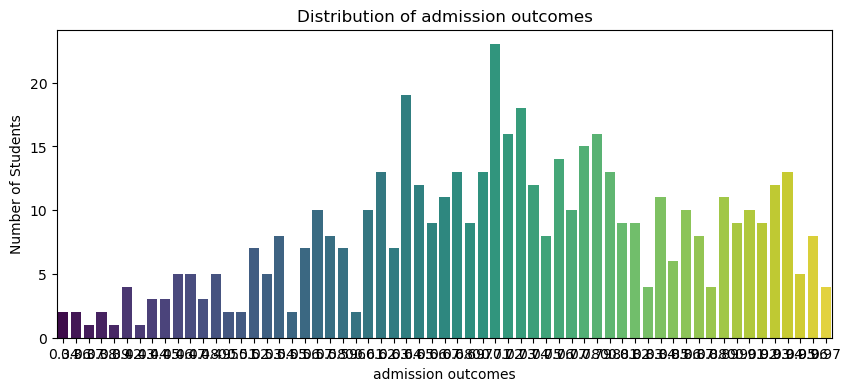

In [44]:
#Admission Chance

plt.figure(figsize=(10, 4))

sb.countplot(x='Chance of Admit ',hue='Chance of Admit ', data=dataset, palette='viridis',legend=False)

plt.title('Distribution of admission outcomes')
plt.xlabel('admission outcomes')
plt.ylabel('Number of Students')

Text(0, 0.5, 'Frequency')

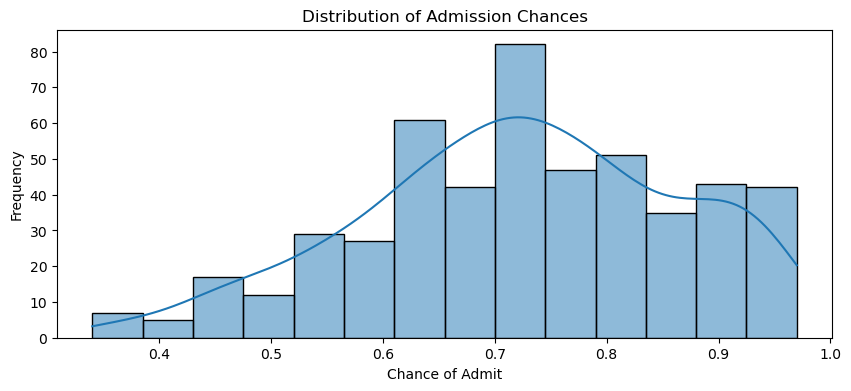

In [45]:
plt.figure(figsize=(10, 4))

sb.histplot(dataset['Chance of Admit '],kde=True)

plt.title('Distribution of Admission Chances')
plt.xlabel('Chance of Admit')
plt.ylabel('Frequency')

### Identify any missing or incorrect values

In [46]:
dataset.isnull().sum()

Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
GPA Scores           0
Research             0
Chance of Admit      0
dtype: int64

In [47]:
### - Check for any outliers or incorrect values
dataset.describe

<bound method NDFrame.describe of      Serial No.  GRE Score  TOEFL Score  University Rating  SOP  LOR   \
0             1        337          118                  4  4.5   4.5   
1             2        324          107                  4  4.0   4.5   
2             3        316          104                  3  3.0   3.5   
3             4        322          110                  3  3.5   2.5   
4             5        314          103                  2  2.0   3.0   
..          ...        ...          ...                ...  ...   ...   
495         496        332          108                  5  4.5   4.0   
496         497        337          117                  5  5.0   5.0   
497         498        330          120                  5  4.5   5.0   
498         499        312          103                  4  4.0   5.0   
499         500        327          113                  4  4.5   4.5   

     GPA Scores  Research  Chance of Admit   
0          9.65         1              0.92

### Perform necessary corrections to the data

In [48]:
## Handle missing values (e.g., fill, drop, or impute)
dataset.dropna()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,GPA Scores,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...,...
495,496,332,108,5,4.5,4.0,9.02,1,0.87
496,497,337,117,5,5.0,5.0,9.87,1,0.96
497,498,330,120,5,4.5,5.0,9.56,1,0.93
498,499,312,103,4,4.0,5.0,8.43,0,0.73


In [49]:
## Handle missing values (e.g., fill, drop, or impute)
dataset.fillna(0) # fro numeric

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,GPA Scores,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...,...
495,496,332,108,5,4.5,4.0,9.02,1,0.87
496,497,337,117,5,5.0,5.0,9.87,1,0.96
497,498,330,120,5,4.5,5.0,9.56,1,0.93
498,499,312,103,4,4.0,5.0,8.43,0,0.73


In [50]:
dataset.fillna('unknown') # for categorical

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,GPA Scores,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...,...
495,496,332,108,5,4.5,4.0,9.02,1,0.87
496,497,337,117,5,5.0,5.0,9.87,1,0.96
497,498,330,120,5,4.5,5.0,9.56,1,0.93
498,499,312,103,4,4.0,5.0,8.43,0,0.73


In [51]:
# Select only numeric columns
numeric_cols = dataset.select_dtypes(include='number').columns

# Identify outliers using IQR method
outliers = {}
for col in numeric_cols:
    Q1 = dataset[col].quantile(0.25)
    Q3 = dataset[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_rows = dataset[(dataset[col] < lower_bound) | (dataset[col] > upper_bound)]
    outliers[col] = outlier_rows.shape[0]

# Display number of outliers per column
print("Outliers detected per column:")
for col, count in outliers.items():
    print(f"{col}: {count} outliers")

Outliers detected per column:
Serial No.: 0 outliers
GRE Score: 0 outliers
TOEFL Score: 0 outliers
University Rating: 0 outliers
SOP: 0 outliers
LOR : 1 outliers
GPA Scores: 0 outliers
Research: 0 outliers
Chance of Admit : 2 outliers


In [52]:
# Handle outliers by capping to lower and upper bounds
for col in dataset.select_dtypes(include='number').columns:
    # Step 1: Calculate Q1, Q3, IQR, and bounds
    Q1 = dataset[col].quantile(0.25)
    Q3 = dataset[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Step 2: Cap the outliers by clipping values to the lower and upper bounds
    dataset[col] = dataset[col].clip(lower=lower_bound, upper=upper_bound)

In [53]:
dataset

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,GPA Scores,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...,...
495,496,332,108,5,4.5,4.0,9.02,1,0.87
496,497,337,117,5,5.0,5.0,9.87,1,0.96
497,498,330,120,5,4.5,5.0,9.56,1,0.93
498,499,312,103,4,4.0,5.0,8.43,0,0.73


In [54]:
import pandas as pd

# 1. Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = dataset['GRE Score'].quantile(0.25)
Q3 = dataset['GRE Score'].quantile(0.75)

# 2. Compute the IQR
IQR = Q3 - Q1

# 3. Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

# 4. Find outliers
outliers = dataset[(dataset['GRE Score'] < lower_bound) | (dataset['GRE Score'] > upper_bound)]

print("Number of outliers in GRE Score:", len(outliers))
print(outliers[['GRE Score']])


Lower Bound: 282.5
Upper Bound: 350.5
Number of outliers in GRE Score: 0
Empty DataFrame
Columns: [GRE Score]
Index: []


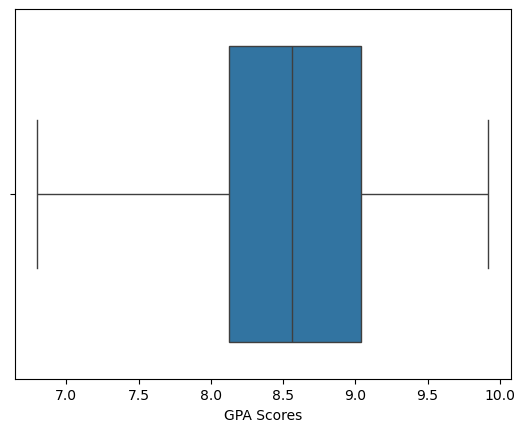

In [55]:
sb.boxplot(x=dataset['GPA Scores']) ## check for outliers in a column
plt.show()

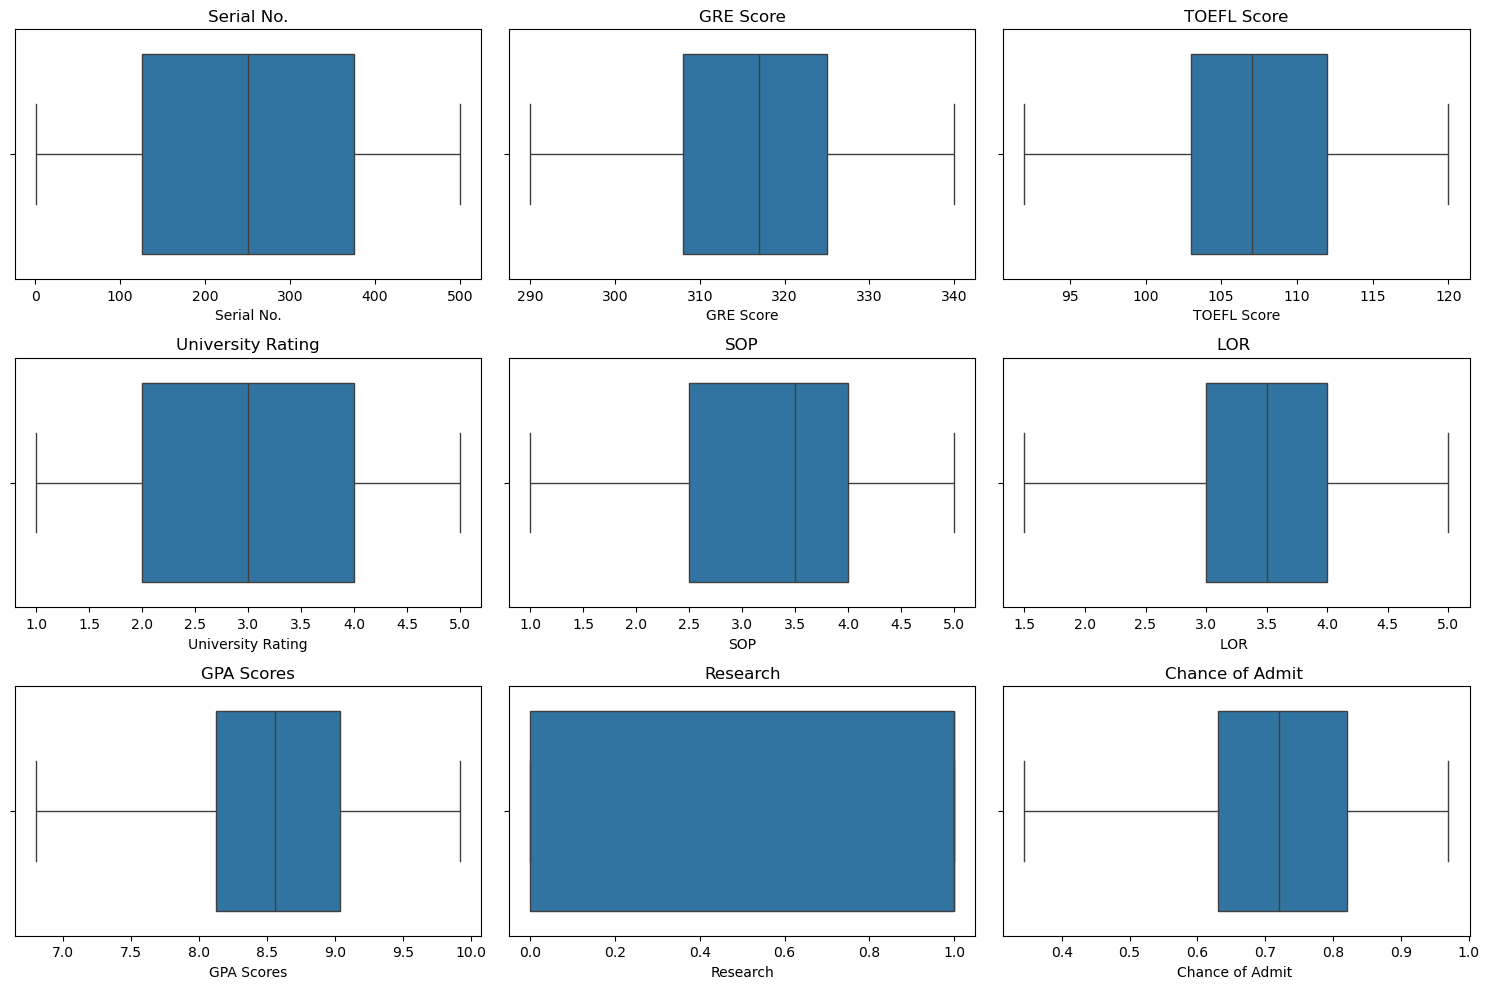

In [56]:

cols = dataset.columns[:9]  # adjust if your 9 columns aren't the first ones

plt.figure(figsize=(15, 10))

for i, col in enumerate(cols, 1):
    plt.subplot(3, 3, i)
    sb.boxplot(x=dataset[col])
    plt.title(col)

plt.tight_layout()
plt.show()


## Create plots to analyze relationships between variables

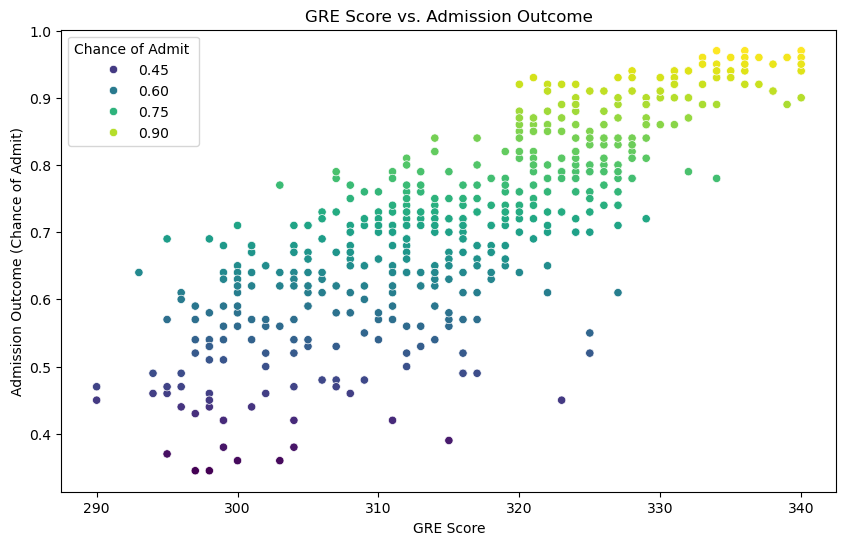

In [58]:
import matplotlib.pyplot as plt
import seaborn as sb

# Create the scatter plot
plt.figure(figsize=(10, 6))
sb.scatterplot(x='GRE Score', y='Chance of Admit ', data=dataset, hue='Chance of Admit ', palette='viridis')

# Add labels and title
plt.title('GRE Score vs. Admission Outcome')
plt.xlabel('GRE Score')
plt.ylabel('Admission Outcome (Chance of Admit)')

# Display the plot
plt.show()


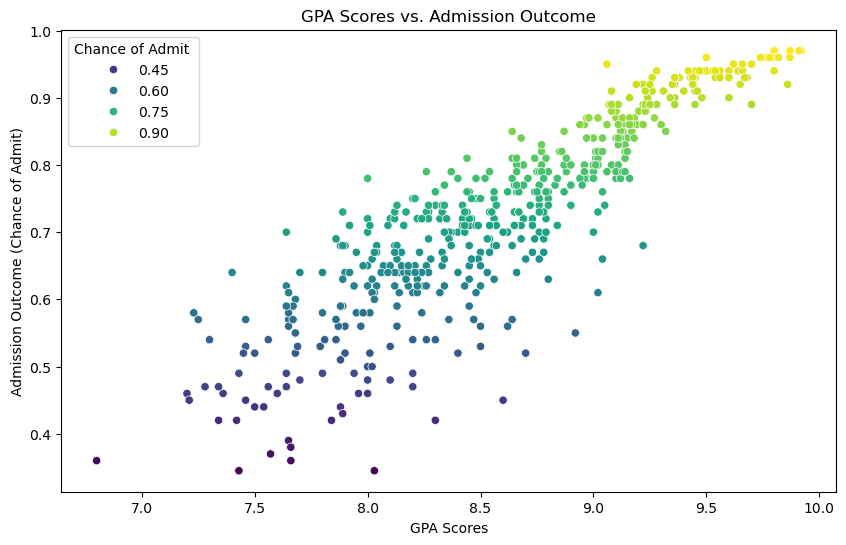

In [77]:
import matplotlib.pyplot as plt
import seaborn as sb

# Create the scatter plot
plt.figure(figsize=(10, 6))
sb.scatterplot(x='GPA Scores', y='Chance of Admit ', data=dataset, hue='Chance of Admit ', palette='viridis')

# Add labels and title
plt.title('GPA Scores vs. Admission Outcome')
plt.xlabel('GPA Scores')
plt.ylabel('Admission Outcome (Chance of Admit)')

# Display the plot
plt.show()


## using Bar plot

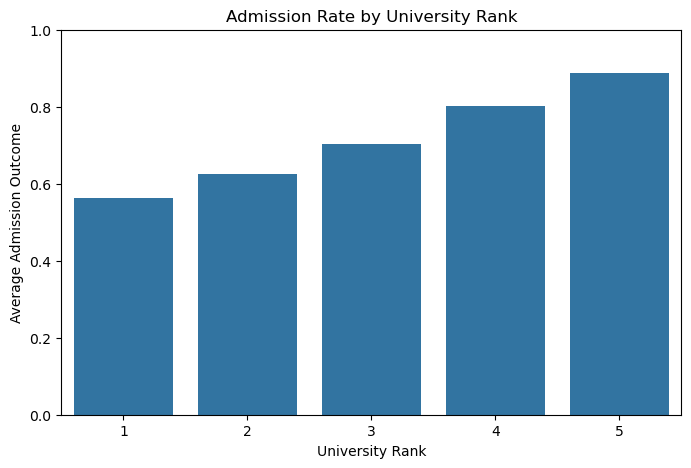

In [61]:

# Group by university rank
rank_outcome = dataset.groupby('University Rating')['Chance of Admit '].mean().reset_index()

# Plot
plt.figure(figsize=(8, 5))
sb.barplot(x='University Rating', y='Chance of Admit ', data=rank_outcome)
plt.title('Admission Rate by University Rank')
plt.xlabel('University Rank')
plt.ylabel('Average Admission Outcome')
plt.ylim(0, 1)
plt.show()


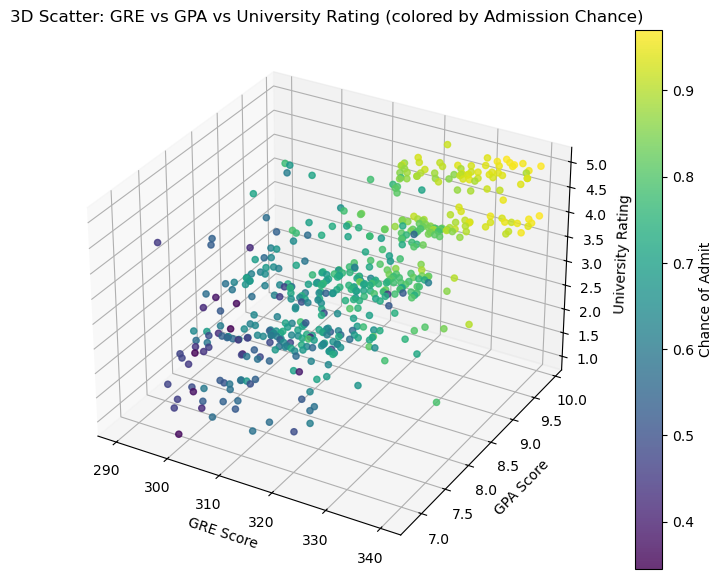

In [80]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create 3D scatter plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot data
sc = ax.scatter(
    dataset['GRE Score'],
    dataset['GPA Scores'],
    dataset['University Rating'],
    c=dataset['Chance of Admit '],
    cmap='viridis',
    alpha=0.8
)

# Set labels
ax.set_xlabel('GRE Score')
ax.set_ylabel('GPA Score')
ax.set_zlabel('University Rating')
plt.title('3D Scatter: GRE vs GPA vs University Rating (colored by Admission Chance)')

# Add colorbar for admission chances
cbar = plt.colorbar(sc)
cbar.set_label('Chance of Admit')

# Show plot
plt.show()


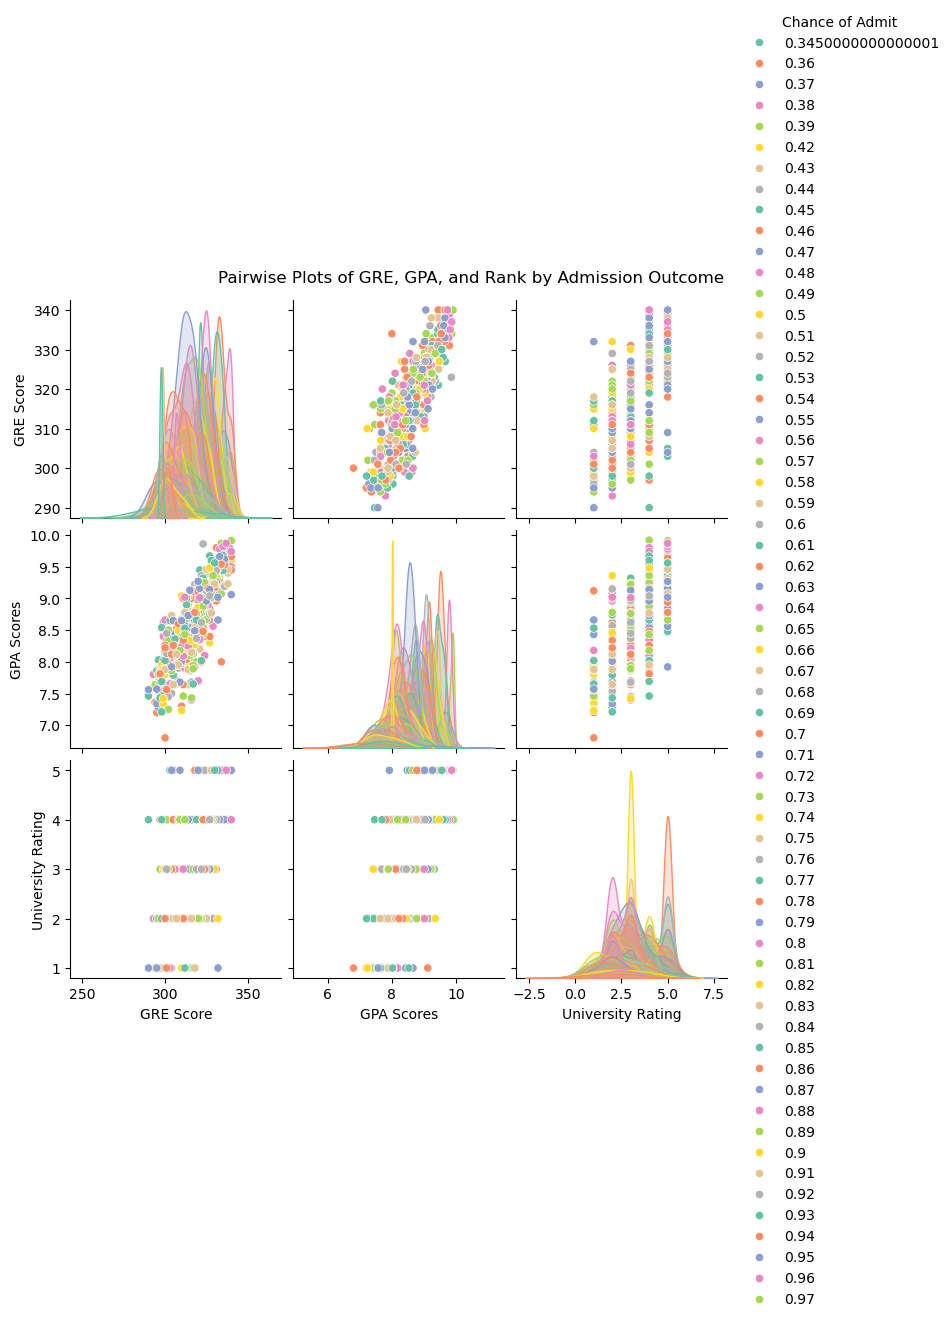

In [81]:
##  Plot combinations of GRE, GPA, and Rank
# Select only the relevant columns
sb.pairplot(dataset, vars=['GRE Score', 'GPA Scores', 'University Rating'], hue='Chance of Admit ', palette='Set2')
plt.suptitle('Pairwise Plots of GRE, GPA, and Rank by Admission Outcome', y=1.02)
plt.show()


In [82]:
dataset.head(2)

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,GPA Scores,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76


## Interpret the results of the visualizations

In [65]:
# Discuss trends or patterns observed in the plots

#The visualizations provide valuable insights into the factors influencing admission decisions at Rwanda Polytechnique. 
#Higher GPA and GRE scores, along with better university ratings, positively correlate with admission chances. 
#These findings can be utilized to build a predictive model that can assist the admissions team in making data-driven decisions. 
#Ensuring a balanced dataset and addressing any imbalances in admission outcomes will further enhance the model's accuracy and reliability.

# Relate observations to potential predictive power

# GRE, GPA, and University Rating are useful for predicting outcomes.

#GPA and GRE Scores: Both features are strong predictors and should be key components of the predictive model.
#University Rating: This feature also holds significant predictive power and should be included to account for the quality of the applicant's previous institution.
#Balanced Dataset: Ensuring a balanced dataset will lead to a more reliable model, as it can better learn the distinction between admitted and non-admitted students.
#By integrating these features into a predictive model, Rwanda Polytechnique can develop a robust system for predicting admission chances. This model can streamline 
#the admissions process, making it more efficient and data-driven.\

### Implement and evaluate various classifiers

In [85]:
#### Implement the model
x=dataset.drop(['Serial No.', 'Chance of Admit '], axis=1)
y=dataset['Chance of Admit ']

In [86]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [87]:
# Implement the model
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(x_train, y_train)

# Predict and record accuracy
y_pred_knn = knn.predict(x_test)
accuracy_knn = r2_score(y_test, y_pred_knn)
print(f'K-Nearest Neighbors Accuracy: {accuracy_knn}')

K-Nearest Neighbors Accuracy: 0.724838630806846


In [88]:
# Implement the model
Decision_Tree = DecisionTreeRegressor(random_state=42)
Decision_Tree.fit(x_train,y_train)

# Predict and record accuracy
y_pred_Dec= Decision_Tree.predict(x_test)
accuracy = r2_score(y_test, y_pred_knn)
print(f'Decision Tree Accuracy: {accuracy}')

Decision Tree Accuracy: 0.724838630806846


In [89]:

# Implement the model
rf = RandomForestRegressor(random_state=42, n_estimators=100)
rf.fit(x_train, y_train)

# Predict and record accuracy
y_pred_rf = rf.predict(x_test)
accuracy_rf = r2_score(y_test, y_pred_rf)
print(f'Random Forest Accuracy: {accuracy_rf}')

Random Forest Accuracy: 0.7854957640586795


In [90]:
# Compare the accuracies
accuracies = {
    'K-Nearest Neighbors': accuracy_knn,
    'Decision Tree': accuracy,
    'Random Forest': accuracy_rf
}

for model, accuracy in accuracies.items():
    print(f'{model} accuracy: {accuracy}')

K-Nearest Neighbors accuracy: 0.724838630806846
Decision Tree accuracy: 0.724838630806846
Random Forest accuracy: 0.7854957640586795


In [91]:
# Analyze and  determine best perfoming model 
highest_accuracy = max(accuracies.values())
best_model = [model for model, accuracy in accuracies.items() if accuracy == highest_accuracy]

if len(best_model) == 1:
    print(f"\nThe best performing model is: {best_model[0]} with an accuracy of {highest_accuracy:.2f}.")
else:
    print(f"\nMultiple models achieved the highest accuracy of {highest_accuracy:.2f}:")
    for model in best_model:
        print(f"- {model}")


The best performing model is: Random Forest with an accuracy of 0.79.
